In [ ]:
# IMPORT LIBRARIES


import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, r2_score

from xgboost import XGBRegressor

# Style and output folder
sns.set_style("whitegrid")
os.makedirs("outputs", exist_ok=True)

print("Libraries loaded successfully")

Libraries loaded successfully


# LOAD DATASET

In [ ]:


import os

BASE_DIR = os.getcwd()

file_path = os.path.join(
    BASE_DIR,
    "dataset",
    "loads_50000_realistic.csv"
)

df = pd.read_csv(file_path)

print("Dataset Loaded Successfully")
print(df.shape)

Dataset Loaded Successfully
(50000, 13)


# FIRST 5 ROWS

In [ ]:

df.head()

,origin_full,destination_full,miles,rate,rpm,deadhead_origin,deadhead_destination,weight,truck_type,pickup_date,delivery_date,broker_name,broker_contact
0,"Seattle, WA","Indianapolis, IN",2212,7211,3.26,161,20,38255,Reefer,2026-05-14,2026-05-16,Echo Global Logistics,800-354-7993
1,"Fargo, ND","Oklahoma City, OK",1458,4986,3.42,104,71,15581,Step Deck,2026-05-14,2026-05-17,Echo Global Logistics,800-354-7993
2,"Fort Worth, TX","Buffalo, NY",1960,4057,2.07,38,11,30304,Flatbed,2026-05-07,2026-05-12,JB Hunt,800-452-4868
3,"Little Rock, AR","Springfield, IL",926,2815,3.04,3,67,18585,Flatbed,2026-05-12,2026-05-17,TQL,800-580-3101
4,"Miami, FL","Little Rock, AR",205,401,1.96,157,84,23905,Dry Van,2026-05-07,2026-05-12,TQL,800-580-3101


# DATASET INFORMATION


In [ ]:



df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   origin_full           50000 non-null  str    
 1   destination_full      50000 non-null  str    
 2   miles                 50000 non-null  int64  
 3   rate                  50000 non-null  int64  
 4   rpm                   50000 non-null  float64
 5   deadhead_origin       50000 non-null  int64  
 6   deadhead_destination  50000 non-null  int64  
 7   weight                50000 non-null  int64  
 8   truck_type            50000 non-null  str    
 9   pickup_date           50000 non-null  str    
 10  delivery_date         50000 non-null  str    
 11  broker_name           50000 non-null  str    
 12  broker_contact        50000 non-null  str    
dtypes: float64(1), int64(5), str(7)
memory usage: 5.0 MB


# DESCRIPTIVE STATISTICS


In [ ]:



df.describe()

,miles,rate,rpm,deadhead_origin,deadhead_destination,weight
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000
mean,1352.83152,3380.118160,2.499591,100.163020,74.818120,27580.58402
std,664.49074,1875.922243,0.577107,58.010816,43.695927,10100.80335
min,200.00000,302.000000,1.500000,0.000000,0.000000,10000.00000
25%,779.00000,1836.000000,2.000000,50.000000,37.000000,18837.00000
50%,1356.00000,3192.000000,2.500000,100.000000,75.000000,27600.00000
75%,1928.00000,4674.250000,3.000000,150.000000,113.000000,36331.25000
max,2500.00000,8711.000000,3.500000,200.000000,150.000000,45000.00000


# MISSING VALUES


In [ ]:



df.isnull().sum()

origin_full             0
destination_full        0
miles                   0
rate                    0
rpm                     0
deadhead_origin         0
deadhead_destination    0
weight                  0
truck_type              0
pickup_date             0
delivery_date           0
broker_name             0
broker_contact          0
dtype: int64

# LOAD RATE DISTRIBUTION


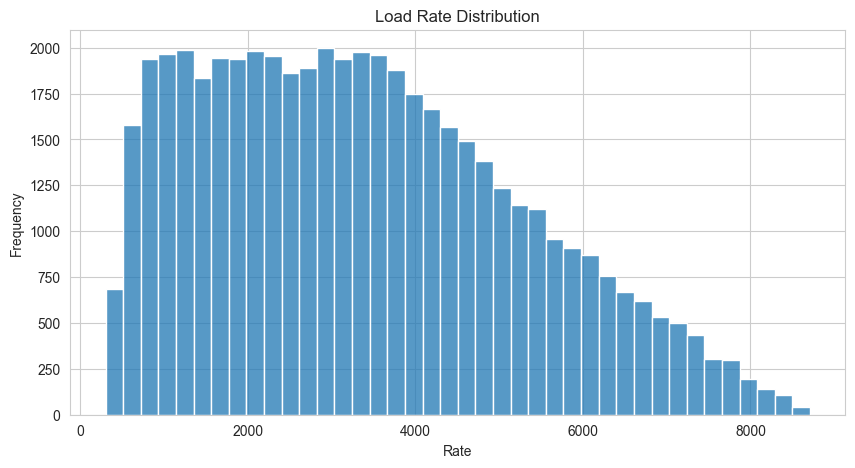

In [ ]:



plt.figure(figsize=(10,5))

sns.histplot(df["rate"], bins=40)

plt.title("Load Rate Distribution")
plt.xlabel("Rate")
plt.ylabel("Frequency")

plt.savefig("outputs/rate_distribution.png")

plt.show()

# FEATURE ENGINEERING


In [ ]:



df["rate_per_mile"] = df["rate"] / df["miles"]

df["total_deadhead"] = (
    df["deadhead_origin"] +
    df["deadhead_destination"]
)

df.head()

,origin_full,destination_full,miles,rate,rpm,deadhead_origin,deadhead_destination,weight,truck_type,pickup_date,delivery_date,broker_name,broker_contact,rate_per_mile,total_deadhead
0,"Seattle, WA","Indianapolis, IN",2212,7211,3.26,161,20,38255,Reefer,2026-05-14,2026-05-16,Echo Global Logistics,800-354-7993,3.259946,181
1,"Fargo, ND","Oklahoma City, OK",1458,4986,3.42,104,71,15581,Step Deck,2026-05-14,2026-05-17,Echo Global Logistics,800-354-7993,3.419753,175
2,"Fort Worth, TX","Buffalo, NY",1960,4057,2.07,38,11,30304,Flatbed,2026-05-07,2026-05-12,JB Hunt,800-452-4868,2.069898,49
3,"Little Rock, AR","Springfield, IL",926,2815,3.04,3,67,18585,Flatbed,2026-05-12,2026-05-17,TQL,800-580-3101,3.039957,70
4,"Miami, FL","Little Rock, AR",205,401,1.96,157,84,23905,Dry Van,2026-05-07,2026-05-12,TQL,800-580-3101,1.956098,241


# RPM(rate per mile) DISTRIBUTION


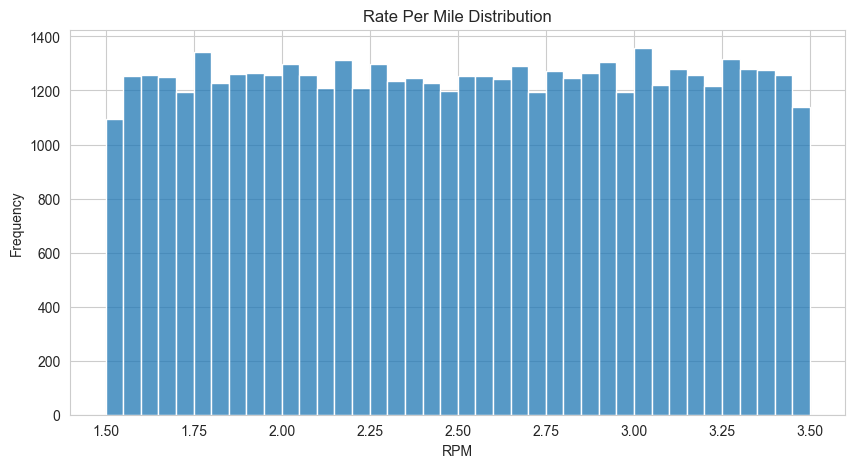

In [ ]:

plt.figure(figsize=(10,5))

sns.histplot(df["rate_per_mile"], bins=40)

plt.title("Rate Per Mile Distribution")
plt.xlabel("RPM")
plt.ylabel("Frequency")

plt.savefig("outputs/rpm_distribution.png")

plt.show()

# TRUCK TYPE ANALYSIS


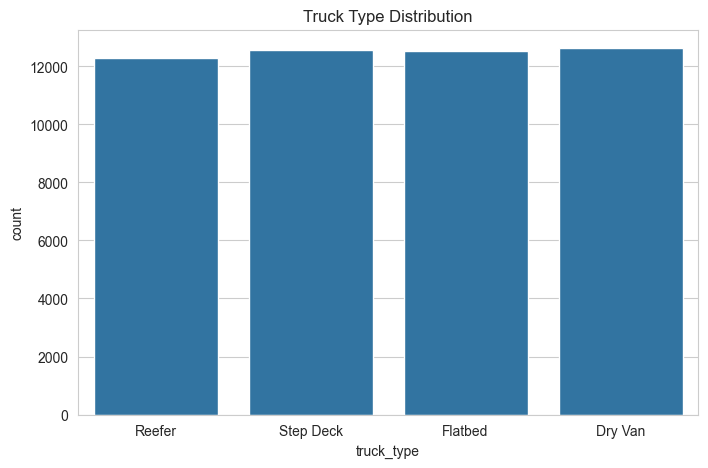

In [ ]:

plt.figure(figsize=(8,5))

sns.countplot(x=df["truck_type"])

plt.title("Truck Type Distribution")

plt.savefig("outputs/truck_distribution.png")

plt.show()

# CORRELATION HEATMAP


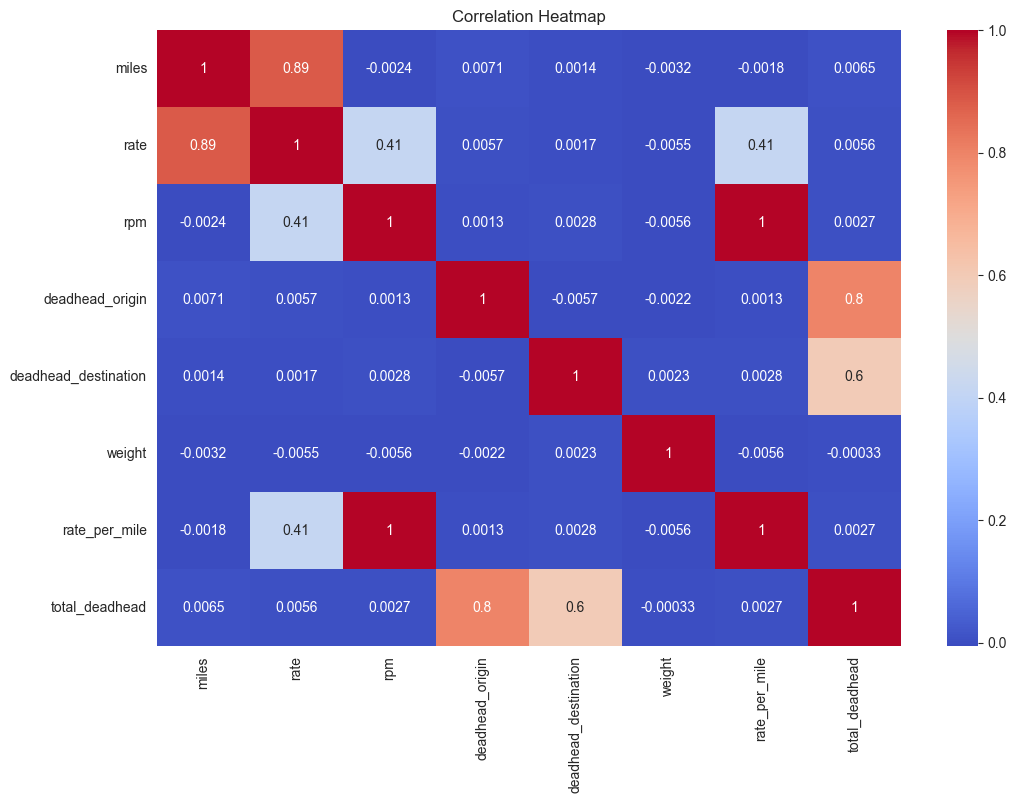

In [ ]:


numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig("outputs/correlation_heatmap.png")

plt.show()

# Truck type count loads

In [ ]:
df["truck_type"].value_counts()

truck_type
Dry Van      12633
Step Deck    12564
Flatbed      12513
Reefer       12290
Name: count, dtype: int64

# Truck Type Disrtibution

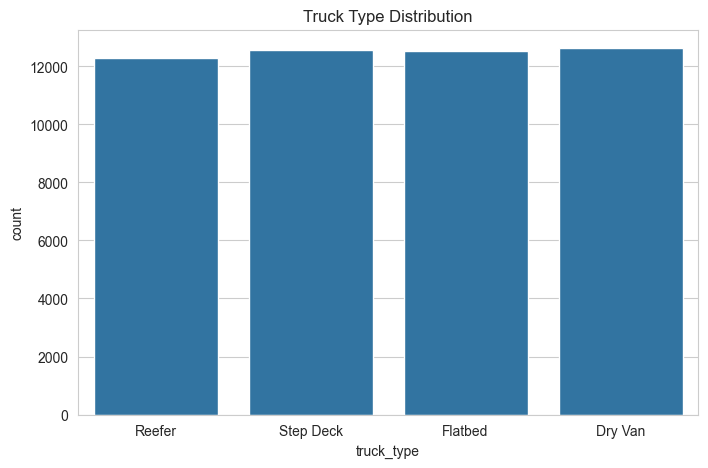

In [62]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="truck_type")
plt.title("Truck Type Distribution")
plt.savefig("outputs/truck_type_distribution.png")
plt.show()


# Miles Vs Rate by Trcuk Type


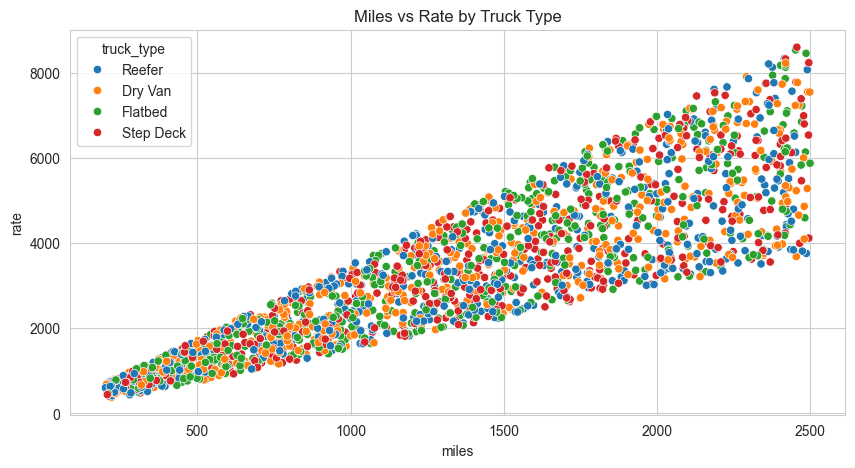

In [63]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df.sample(2000), x="miles", y="rate", hue="truck_type")
plt.title("Miles vs Rate by Truck Type")
plt.savefig("outputs/miles_vs_rate.png")
plt.show()

# Rate Distribution by Truck Type

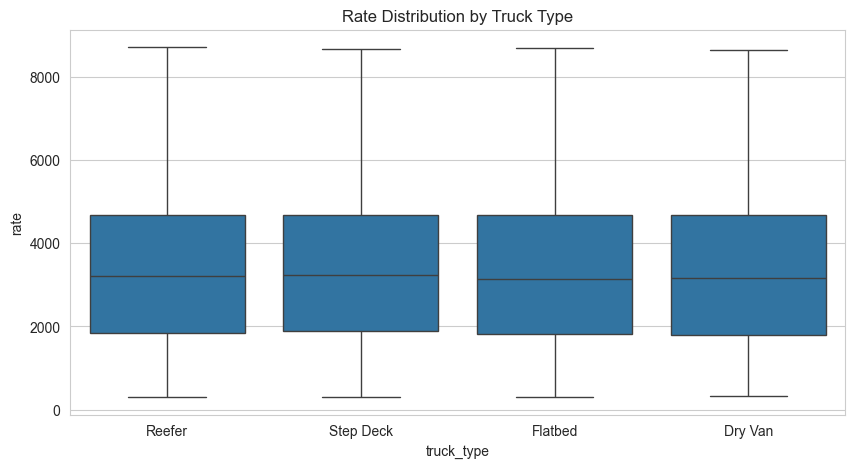

In [64]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="truck_type", y="rate")
plt.title("Rate Distribution by Truck Type")
plt.savefig("outputs/rate_by_truck_type.png")
plt.show()


# Heat Map

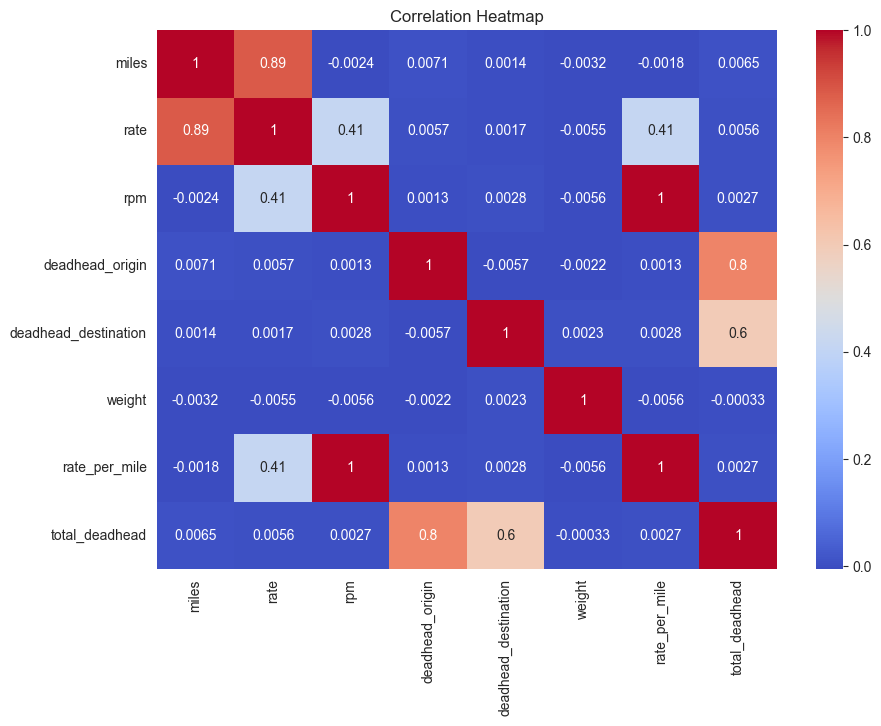

In [65]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,7))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("outputs/correlation_heatmap.png")
plt.show()

# Feature Engineering

In [ ]:
# FEATURE ENGINEERING


df["rate_per_mile"] = (
    df["rate"] / df["miles"]
)

df["total_deadhead"] = (
    df["deadhead_origin"] +
    df["deadhead_destination"]
)

df["efficiency"] = (
    df["rate"] /
    (df["miles"] + df["total_deadhead"])
)

df["profit_estimate"] = (
    df["rate"] -
    (df["total_deadhead"] * 2)
)

df.head()

,origin_full,destination_full,miles,rate,rpm,deadhead_origin,deadhead_destination,weight,truck_type,pickup_date,delivery_date,broker_name,broker_contact,rate_per_mile,total_deadhead,efficiency,profit_estimate
0,"Seattle, WA","Indianapolis, IN",2212,7211,3.26,161,20,38255,Reefer,2026-05-14,2026-05-16,Echo Global Logistics,800-354-7993,3.259946,181,3.013372,6849
1,"Fargo, ND","Oklahoma City, OK",1458,4986,3.42,104,71,15581,Step Deck,2026-05-14,2026-05-17,Echo Global Logistics,800-354-7993,3.419753,175,3.053276,4636
2,"Fort Worth, TX","Buffalo, NY",1960,4057,2.07,38,11,30304,Flatbed,2026-05-07,2026-05-12,JB Hunt,800-452-4868,2.069898,49,2.019413,3959
3,"Little Rock, AR","Springfield, IL",926,2815,3.04,3,67,18585,Flatbed,2026-05-12,2026-05-17,TQL,800-580-3101,3.039957,70,2.826305,2675
4,"Miami, FL","Little Rock, AR",205,401,1.96,157,84,23905,Dry Van,2026-05-07,2026-05-12,TQL,800-580-3101,1.956098,241,0.899103,-81


# Target Variable Creation

In [ ]:
# TARGET SCORE CREATION


df["load_score"] = (
    (df["rate_per_mile"] * 15)
    + (df["rate"] / 800)
    - (df["total_deadhead"] * 0.05)
    - (df["weight"] / 120000)
    + (df["efficiency"] * 10)
)

df[[
    "rate_per_mile",
    "efficiency",
    "profit_estimate",
    "load_score"
]].head()

,rate_per_mile,efficiency,profit_estimate,load_score
0,3.259946,3.013372,6849,78.677868
1,3.419753,3.053276,4636,79.181716
2,2.069898,2.019413,3959,53.611312
3,3.039957,2.826305,2675,73.726279
4,1.956098,0.899103,-81,26.584536


# Feature Selection

In [ ]:
# SELECT FEATURES


features = [
    "miles",
    "rate",
    "deadhead_origin",
    "deadhead_destination",
    "weight",
    "rate_per_mile",
    "total_deadhead",
    "efficiency",
    "profit_estimate",
    "truck_type",
    "origin_full",
    "destination_full"
]

target = "load_score"

X = df[features]
y = df[target]

print(X.shape)
print(y.shape)

(50000, 12)
(50000,)


# Train Test Split

In [ ]:

# TRAIN TEST SPLIT


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(40000, 12)
(10000, 12)


# Data Preprocessing Pipeline

In [ ]:

# PREPROCESSING PIPELINE


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

numeric_features = [
    "miles",
    "rate",
    "deadhead_origin",
    "deadhead_destination",
    "weight",
    "rate_per_mile",
    "total_deadhead",
    "efficiency",
    "profit_estimate"
]

categorical_features = [
    "truck_type",
    "origin_full",
    "destination_full"
]

preprocessor = ColumnTransformer([
    (
        "num",
        StandardScaler(),
        numeric_features
    ),
    (
        "cat",
        OneHotEncoder(handle_unknown="ignore"),
        categorical_features
    )
])

print("Preprocessing pipeline created successfully")

Preprocessing pipeline created successfully


# Machine Learning Models

In [ ]:
# IMPORT ML MODELS


from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

print("Models imported successfully")

Models imported successfully


# DEFINE MODELS

In [ ]:


models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=10,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
}

print(models.keys())

dict_keys(['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost'])


# Model Training and Evaluation

In [ ]:
# TRAIN MODELS


from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)

results = []

trained_models = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    results.append({
        "Model": name,
        "MAE": round(mae, 3),
        "R2 Score": round(r2, 3)
    })

    trained_models[name] = pipeline

    print(f"{name} completed")

Linear Regression completed
Decision Tree completed
Random Forest completed
XGBoost completed


In [ ]:
# RESULTS TABLE


results_df = pd.DataFrame(results)

results_df

,Model,MAE,R2 Score
0,Linear Regression,0.000,1.000
1,Decision Tree,0.636,0.997
2,Random Forest,0.234,1.000
3,XGBoost,0.162,1.000


# MODEL COMPARISON GRAPH


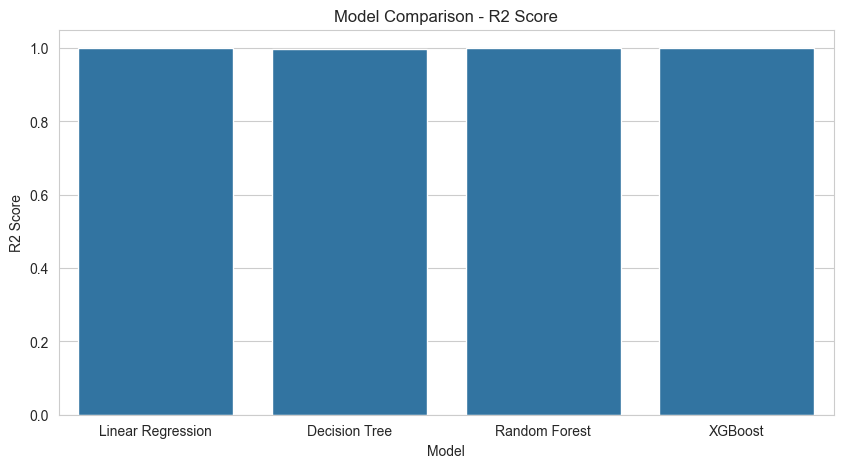

In [ ]:

plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="R2 Score"
)

plt.title("Model Comparison - R2 Score")

plt.savefig("outputs/model_comparison.png")

plt.show()

# BEST MODELs


In [ ]:

best_model = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

best_model

,Model,MAE,R2 Score
0,Linear Regression,0.000,1.000
2,Random Forest,0.234,1.000
3,XGBoost,0.162,1.000
1,Decision Tree,0.636,0.997


XGBoost achieved the highest R² score due to its ability to model complex nonlinear relationships within freight pricing and operational variables.

# Best Model Selection

In [ ]:
# SELECT BEST MODEL

best_model_name = results_df.sort_values(
    by="R2 Score",
    ascending=False
).iloc[0]["Model"]

best_pipeline = trained_models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Linear Regression


# PREDICTION VS ACTUAL


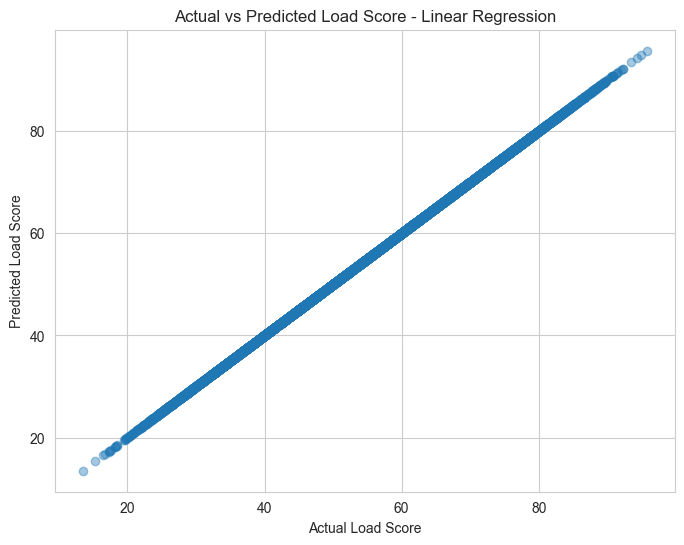

In [ ]:

y_pred = best_pipeline.predict(X_test)

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.4)

plt.xlabel("Actual Load Score")
plt.ylabel("Predicted Load Score")
plt.title(f"Actual vs Predicted Load Score - {best_model_name}")

plt.savefig("outputs/actual_vs_predicted.png")

plt.show()

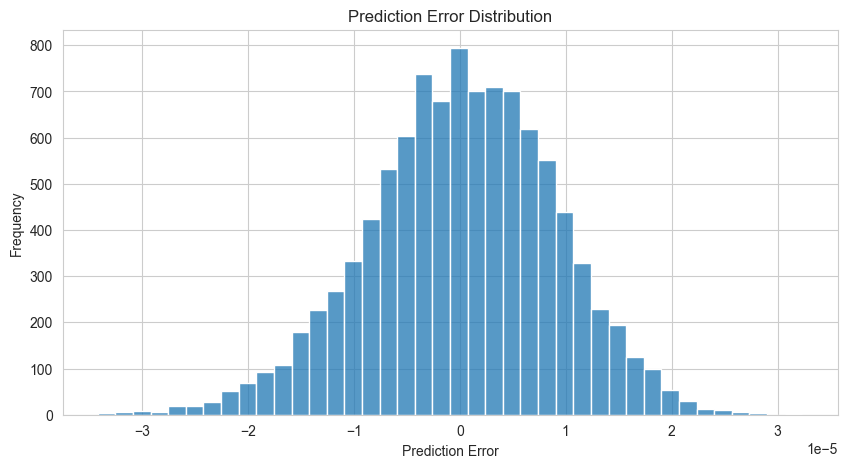

In [ ]:
# ERROR DISTRIBUTION
# -------------------

errors = y_test - y_pred

plt.figure(figsize=(10,5))

sns.histplot(errors, bins=40)

plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.savefig("outputs/error_distribution.png")

plt.show()

In [ ]:

# FEATURE IMPORTANCE
# -------------------


model_step = best_pipeline.named_steps["model"]

if hasattr(model_step, "feature_importances_"):
    feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model_step.feature_importances_
    })

    importance_df = importance_df.sort_values(
        by="Importance",
        ascending=False
    ).head(15)

    plt.figure(figsize=(10,6))

    sns.barplot(
        data=importance_df,
        x="Importance",
        y="Feature"
    )

    plt.title(f"Top 15 Feature Importances - {best_model_name}")

    plt.savefig("outputs/feature_importance.png", bbox_inches="tight")

    plt.show()

    importance_df
else:
    print("Feature importance is not available for this model.")

Feature importance is not available for this model.


In [ ]:

# SAVE MODEL RESULTS
# ------------------


results_df.to_csv("outputs/model_results.csv", index=False)

print("Model results saved successfully")

Model results saved successfully


The model comparison results show how different machine learning algorithms performed on the freight load scoring task. Linear Regression was used as a baseline model, while Decision Tree, Random Forest, and XGBoost were used to capture non-linear relationships in the dataset. The best-performing model was selected based on R² score and Mean Absolute Error. The actual-versus-predicted graph shows how closely the model predictions align with the engineered load suitability score, while the error distribution helps identify whether prediction errors are concentrated around zero. Feature importance analysis provides interpretability by showing which variables had the greatest influence on load ranking decisions.

# Driver Dataset Integration

This section extends the project from general load ranking into a driver–load matching problem. A separate driver dataset is integrated with the freight load dataset so that the model can learn whether a load is suitable for a specific driver based on truck type, weight, deadhead distance, destination preference, driver rating, and experience.


In [ ]:
# LOAD OR CREATE DRIVER DATASET
# -----------------------------


DRIVERS_PATH = os.path.join(BASE_DIR, "dataset", "drivers.csv")

# If drivers.csv is not available, create a 15-driver dataset automatically
if not os.path.exists(DRIVERS_PATH):
    drivers = [
        [1, "Shawn", "Dallas, TX", "Dry Van", "53 ft", 45000, 150, "Atlanta, GA", 4.8, 10, 1],
        [2, "Issac", "Dallas, TX", "Flatbed", "53 ft", 48000, 120, "Chicago, IL", 4.5, 7, 1],
        [3, "Michael", "Fort Worth, TX", "Dry Van", "53 ft", 44000, 100, "Phoenix, AZ", 4.6, 8, 1],
        [4, "David", "Houston, TX", "Reefer", "53 ft", 43000, 180, "Miami, FL", 4.7, 9, 1],
        [5, "Robert", "Chicago, IL", "Dry Van", "53 ft", 45000, 130, "New York, NY", 4.4, 6, 1],
        [6, "Anthony", "Atlanta, GA", "Reefer", "53 ft", 42000, 160, "Orlando, FL", 4.9, 11, 1],
        [7, "James", "Los Angeles, CA", "Dry Van", "53 ft", 44000, 150, "Las Vegas, NV", 4.3, 5, 1],
        [8, "William", "Phoenix, AZ", "Flatbed", "48 ft", 47000, 140, "Denver, CO", 4.5, 6, 1],
        [9, "Daniel", "Miami, FL", "Reefer", "53 ft", 42000, 110, "Atlanta, GA", 4.6, 8, 1],
        [10, "Chris", "Denver, CO", "Step Deck", "53 ft", 46000, 200, "Salt Lake City, UT", 4.2, 4, 1],
        [11, "Kevin", "Seattle, WA", "Dry Van", "53 ft", 44000, 170, "Boise, ID", 4.7, 9, 1],
        [12, "Brian", "Nashville, TN", "Flatbed", "53 ft", 48000, 140, "Charlotte, NC", 4.4, 6, 1],
        [13, "Mark", "Kansas City, MO", "Dry Van", "53 ft", 45000, 130, "Indianapolis, IN", 4.6, 7, 1],
        [14, "Steven", "Charlotte, NC", "Reefer", "53 ft", 42000, 160, "Philadelphia, PA", 4.8, 10, 1],
        [15, "Andrew", "Orlando, FL", "Dry Van", "53 ft", 44000, 120, "Houston, TX", 4.3, 5, 1],
    ]

    driver_columns = [
        "driver_id", "driver_name", "current_location", "truck_type",
        "truck_length", "max_weight", "max_deadhead",
        "preferred_destination", "driver_rating", "experience_years",
        "availability"
    ]

    drivers_df = pd.DataFrame(drivers, columns=driver_columns)
    drivers_df.to_csv(DRIVERS_PATH, index=False)
    print("drivers.csv was created automatically")
else:
    drivers_df = pd.read_csv(DRIVERS_PATH)
    print("drivers.csv loaded successfully")

print("Drivers dataset shape:", drivers_df.shape)
drivers_df.head()


drivers.csv loaded successfully
Drivers dataset shape: (15, 11)


,driver_id,driver_name,current_location,truck_type,truck_length,max_weight,max_deadhead,preferred_destination,driver_rating,experience_years,availability
0,1,Shawn,"Dallas, TX",Dry Van,53 ft,45000,150,"Atlanta, GA",4.8,10,1
1,2,Issac,"Dallas, TX",Flatbed,53 ft,48000,120,"Chicago, IL",4.5,7,1
2,3,Michael,"Fort Worth, TX",Dry Van,53 ft,44000,100,"Phoenix, AZ",4.6,8,1
3,4,David,"Houston, TX",Reefer,53 ft,43000,180,"Miami, FL",4.7,9,1
4,5,Robert,"Chicago, IL",Dry Van,53 ft,45000,130,"New York, NY",4.4,6,1


In [ ]:
# DRIVER DATASET OVERVIEW
# ------------------------


drivers_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   driver_id              15 non-null     int64  
 1   driver_name            15 non-null     str    
 2   current_location       15 non-null     str    
 3   truck_type             15 non-null     str    
 4   truck_length           15 non-null     str    
 5   max_weight             15 non-null     int64  
 6   max_deadhead           15 non-null     int64  
 7   preferred_destination  15 non-null     str    
 8   driver_rating          15 non-null     float64
 9   experience_years       15 non-null     int64  
 10  availability           15 non-null     int64  
dtypes: float64(1), int64(5), str(5)
memory usage: 1.4 KB


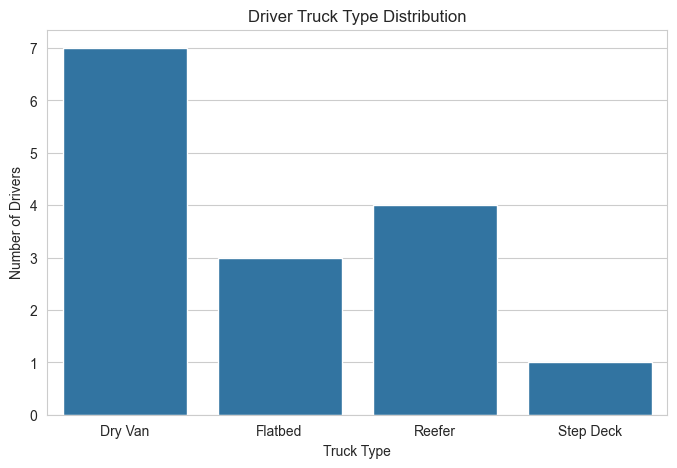

In [ ]:
# DRIVER TRUCK TYPE DISTRIBUTION
# ------------------------------


plt.figure(figsize=(8, 5))
sns.countplot(data=drivers_df, x="truck_type")

plt.title("Driver Truck Type Distribution")
plt.xlabel("Truck Type")
plt.ylabel("Number of Drivers")

plt.savefig("outputs/driver_truck_type_distribution.png")
plt.show()


In [ ]:
# CREATE DRIVER-LOAD TRAINING DATA
# --------------------------------

# A sample is used to keep training computationally manageable.
# 15 drivers x 10,000 loads = 150,000 driver-load examples.
loads_sample = df.sample(10000, random_state=42).reset_index(drop=True)

training_rows = []

for _, driver in drivers_df.iterrows():

    for _, load in loads_sample.iterrows():

        truck_match = 1 if driver["truck_type"] == load["truck_type"] else 0
        destination_match = 1 if driver["preferred_destination"] == load["destination_full"] else 0
        weight_ok = 1 if load["weight"] <= driver["max_weight"] else 0
        deadhead_ok = 1 if load["deadhead_origin"] <= driver["max_deadhead"] else 0

        rpm = load["rate"] / load["miles"]
        total_deadhead = load["deadhead_origin"] + load["deadhead_destination"]

        match_score = (
            (rpm * 15)
            + (load["rate"] / 800)
            + (truck_match * 5)
            + (destination_match * 4)
            + (weight_ok * 3)
            + (deadhead_ok * 3)
            + (driver["driver_rating"] * 1.5)
            + (driver["experience_years"] * 0.2)
            - (total_deadhead * 0.05)
        )

        training_rows.append({
            "driver_id": driver["driver_id"],
            "driver_name": driver["driver_name"],
            "driver_location": driver["current_location"],
            "driver_truck_type": driver["truck_type"],
            "truck_length": driver["truck_length"],
            "driver_rating": driver["driver_rating"],
            "experience_years": driver["experience_years"],
            "max_weight": driver["max_weight"],
            "max_deadhead": driver["max_deadhead"],
            "preferred_destination": driver["preferred_destination"],

            "origin_full": load["origin_full"],
            "destination_full": load["destination_full"],
            "miles": load["miles"],
            "rate": load["rate"],
            "rpm": rpm,
            "deadhead_origin": load["deadhead_origin"],
            "deadhead_destination": load["deadhead_destination"],
            "total_deadhead": total_deadhead,
            "weight": load["weight"],
            "load_truck_type": load["truck_type"],
            "broker_name": load["broker_name"],
            "broker_contact": load["broker_contact"],

            "truck_match": truck_match,
            "destination_match": destination_match,
            "weight_ok": weight_ok,
            "deadhead_ok": deadhead_ok,

            "match_score": match_score
        })

driver_load_df = pd.DataFrame(training_rows)

print("Driver-load training dataset created")
print("Shape:", driver_load_df.shape)

driver_load_df.head()


Driver-load training dataset created
Shape: (150000, 27)


,driver_id,driver_name,driver_location,driver_truck_type,truck_length,driver_rating,experience_years,max_weight,max_deadhead,preferred_destination,...,total_deadhead,weight,load_truck_type,broker_name,broker_contact,truck_match,destination_match,weight_ok,deadhead_ok,match_score
0,1,Shawn,"Dallas, TX",Dry Van,53 ft,4.8,10,45000,150,"Atlanta, GA",...,228,36285,Reefer,XPO Logistics,800-755-2728,0,0,1,0,50.979411
1,1,Shawn,"Dallas, TX",Dry Van,53 ft,4.8,10,45000,150,"Atlanta, GA",...,282,28400,Flatbed,TQL,800-580-3101,0,0,1,0,34.179652
2,1,Shawn,"Dallas, TX",Dry Van,53 ft,4.8,10,45000,150,"Atlanta, GA",...,102,23256,Dry Van,Echo Global Logistics,800-354-7993,1,0,1,1,59.616971
3,1,Shawn,"Dallas, TX",Dry Van,53 ft,4.8,10,45000,150,"Atlanta, GA",...,146,37958,Flatbed,XPO Logistics,800-755-2728,0,0,1,1,42.537510
4,1,Shawn,"Dallas, TX",Dry Van,53 ft,4.8,10,45000,150,"Atlanta, GA",...,178,34799,Flatbed,Landstar,800-872-9400,0,0,1,1,61.840000


In [ ]:
# SAVE DRIVER-LOAD TRAINING DATA
# ------------------------------

driver_load_df.to_csv(
    os.path.join(BASE_DIR, "dataset", "driver_load_training.csv"),
    index=False
)

print("Saved: dataset/driver_load_training.csv")


Saved: dataset/driver_load_training.csv


In [ ]:
# DRIVER-LOAD DATASET SUMMARY
# --------------------------

driver_load_df.describe()


,driver_id,driver_rating,experience_years,max_weight,max_deadhead,miles,rate,rpm,deadhead_origin,deadhead_destination,total_deadhead,weight,truck_match,destination_match,weight_ok,deadhead_ok,match_score
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,8.000000,4.553333,7.400000,44600.000000,144.000000,1345.442400,3360.059400,2.496521,100.224700,75.212800,175.437500,27731.547300,0.252020,0.022567,0.969767,0.722593,47.613459
std,4.320508,0.199556,2.026498,1925.276961,26.280625,663.502343,1871.126886,0.574067,57.777493,43.831262,72.473379,10097.281674,0.434174,0.148518,0.171229,0.447720,11.020626
min,1.000000,4.200000,4.000000,42000.000000,100.000000,200.000000,302.000000,1.498674,0.000000,0.000000,0.000000,10000.000000,0.000000,0.000000,0.000000,0.000000,17.665864
25%,4.000000,4.400000,6.000000,43000.000000,120.000000,770.750000,1816.500000,2.000000,51.000000,38.000000,123.000000,19033.750000,0.000000,0.000000,1.000000,0.000000,39.194012
50%,8.000000,4.600000,7.000000,44000.000000,140.000000,1347.500000,3158.500000,2.489725,100.000000,76.000000,177.000000,27744.000000,0.000000,0.000000,1.000000,1.000000,47.442356
75%,12.000000,4.700000,9.000000,46000.000000,160.000000,1912.000000,4643.000000,2.989832,150.000000,113.000000,228.000000,36464.000000,1.000000,0.000000,1.000000,1.000000,55.996730
max,15.000000,4.900000,11.000000,48000.000000,200.000000,2500.000000,8676.000000,3.500000,200.000000,150.000000,348.000000,45000.000000,1.000000,1.000000,1.000000,1.000000,81.867987


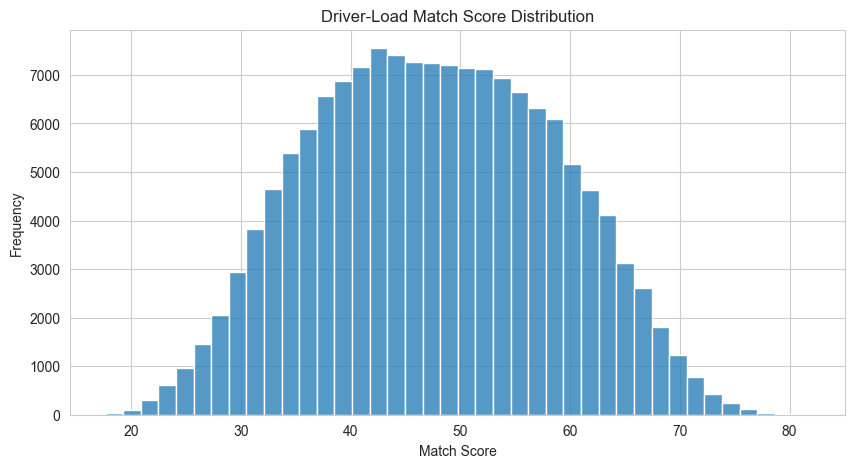

In [ ]:
# MATCH SCORE DISTRIBUTION
# ------------------------


plt.figure(figsize=(10, 5))
sns.histplot(driver_load_df["match_score"], bins=40)

plt.title("Driver-Load Match Score Distribution")
plt.xlabel("Match Score")
plt.ylabel("Frequency")

plt.savefig("outputs/driver_match_score_distribution.png")
plt.show()


# Driver–Load Matching Model

The following section trains machine learning models using the generated driver–load training dataset. This improves the project by moving from general load ranking to personalised driver–load matching.


In [ ]:
# DRIVER-LOAD FEATURE SELECTION
# ==============================

driver_features = [
    "driver_rating",
    "experience_years",
    "max_weight",
    "max_deadhead",
    "miles",
    "rate",
    "rpm",
    "deadhead_origin",
    "deadhead_destination",
    "total_deadhead",
    "weight",
    "truck_match",
    "destination_match",
    "weight_ok",
    "deadhead_ok",
    "driver_truck_type",
    "load_truck_type",
    "driver_location",
    "preferred_destination",
    "origin_full",
    "destination_full"
]

driver_target = "match_score"

X_driver = driver_load_df[driver_features]
y_driver = driver_load_df[driver_target]

print("X_driver shape:", X_driver.shape)
print("y_driver shape:", y_driver.shape)


X_driver shape: (150000, 21)
y_driver shape: (150000,)


In [ ]:
# DRIVER-LOAD TRAIN TEST SPLIT
# ----------------------------


X_driver_train, X_driver_test, y_driver_train, y_driver_test = train_test_split(
    X_driver,
    y_driver,
    test_size=0.2,
    random_state=42
)

print("Training shape:", X_driver_train.shape)
print("Testing shape:", X_driver_test.shape)


Training shape: (120000, 21)
Testing shape: (30000, 21)


In [ ]:
# DRIVER-LOAD PREPROCESSING PIPELINE
# ----------------------------------

driver_numeric_features = [
    "driver_rating",
    "experience_years",
    "max_weight",
    "max_deadhead",
    "miles",
    "rate",
    "rpm",
    "deadhead_origin",
    "deadhead_destination",
    "total_deadhead",
    "weight",
    "truck_match",
    "destination_match",
    "weight_ok",
    "deadhead_ok"
]

driver_categorical_features = [
    "driver_truck_type",
    "load_truck_type",
    "driver_location",
    "preferred_destination",
    "origin_full",
    "destination_full"
]

driver_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), driver_numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), driver_categorical_features)
])

print("Driver-load preprocessing pipeline created")


Driver-load preprocessing pipeline created


In [ ]:

# DEFINE DRIVER-LOAD MODELS
# -------------------------


driver_models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=10,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
}

print("Driver-load models ready")


Driver-load models ready


In [93]:
# TRAIN AND EVALUATE DRIVER-LOAD MODELS
# -------------------------------------

driver_results = []
driver_trained_models = {}

for name, model in driver_models.items():

    pipeline = Pipeline([
        ("preprocessor", driver_preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_driver_train, y_driver_train)

    predictions = pipeline.predict(X_driver_test)

    mae = mean_absolute_error(y_driver_test, predictions)
    r2 = r2_score(y_driver_test, predictions)

    driver_results.append({
        "Model": name,
        "MAE": round(mae, 3),
        "R2 Score": round(r2, 3)
    })

    driver_trained_models[name] = pipeline

    print(f"{name} completed")


Linear Regression completed
Decision Tree completed
Random Forest completed
XGBoost completed


In [94]:
# =====================================
# DRIVER-LOAD RESULTS TABLE
# =====================================

driver_results_df = pd.DataFrame(driver_results)

driver_results_df


,Model,MAE,R2 Score
0,Linear Regression,0.000,1.000
1,Decision Tree,1.127,0.982
2,Random Forest,0.614,0.994
3,XGBoost,0.183,1.000


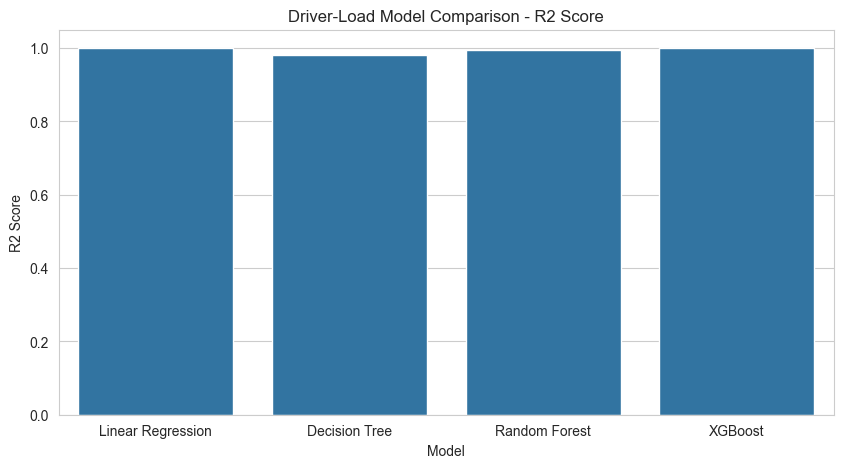

In [ ]:
# DRIVER-LOAD MODEL COMPARISON GRAPH
# ----------------------------------


plt.figure(figsize=(10, 5))
sns.barplot(
    data=driver_results_df,
    x="Model",
    y="R2 Score"
)

plt.title("Driver-Load Model Comparison - R2 Score")
plt.xlabel("Model")
plt.ylabel("R2 Score")

plt.savefig("outputs/driver_load_model_comparison.png")
plt.show()


In [96]:

# BEST DRIVER-LOAD MODEL


best_driver_model_name = driver_results_df.sort_values(
    by="R2 Score",
    ascending=False
).iloc[0]["Model"]

best_driver_pipeline = driver_trained_models[best_driver_model_name]

print("Best Driver-Load Model:", best_driver_model_name)


Best Driver-Load Model: Linear Regression


In [97]:
# SAVE DRIVER-LOAD MODEL RESULTS


driver_results_df.to_csv(
    "outputs/driver_load_model_results.csv",
    index=False
)

print("Driver-load model results saved successfully")


Driver-load model results saved successfully


IMPORT TUNING LIBRARIES

In [98]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error

XGBOOST HYPERPARAMETER TUNING

In [99]:
xgb_pipeline = Pipeline([
    ("preprocessor", driver_preprocessor),
    ("model", XGBRegressor(random_state=42))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [6, 8],
    "model__learning_rate": [0.05, 0.1]
}

grid_search = GridSearchCV(
    xgb_pipeline,
    param_grid,
    cv=3,
    scoring="r2",
    verbose=2,
    n_jobs=-1
)

grid_search.fit(
    X_driver_train,
    y_driver_train
)

print("Best Parameters:")
print(grid_search.best_params_)

print("Best CV Score:")
print(grid_search.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 8, 'model__n_estimators': 200}
Best CV Score:
0.9994004355396792


TUNED MODEL EVALUATION

In [100]:


best_tuned_model = grid_search.best_estimator_

tuned_predictions = best_tuned_model.predict(X_driver_test)

tuned_mae = mean_absolute_error(
    y_driver_test,
    tuned_predictions
)

tuned_r2 = r2_score(
    y_driver_test,
    tuned_predictions
)

tuned_rmse = np.sqrt(
    mean_squared_error(
        y_driver_test,
        tuned_predictions
    )
)

print("Tuned Model Results")
print("---------------------")
print("MAE:", round(tuned_mae, 3))
print("R2 Score:", round(tuned_r2, 3))
print("RMSE:", round(tuned_rmse, 3))

Tuned Model Results
---------------------
MAE: 0.191
R2 Score: 0.999
RMSE: 0.25


Hyperparameter tuning was performed using GridSearchCV to optimize the XGBoost model. Parameters including learning rate, tree depth, and number of estimators were tuned using 3-fold cross-validation

# learning curve

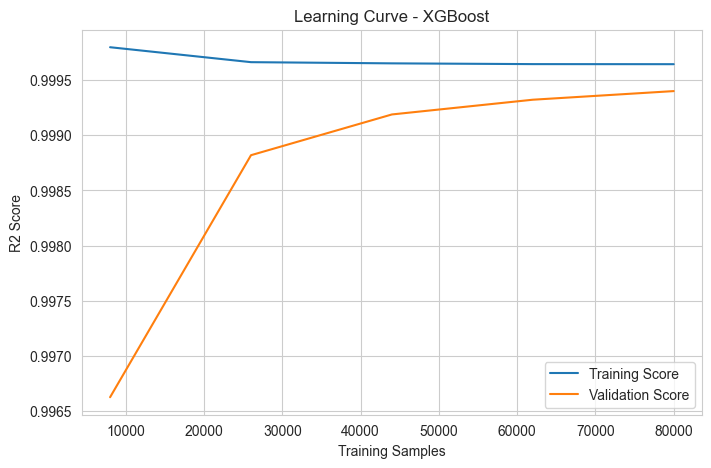

In [102]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_tuned_model,
    X_driver_train,
    y_driver_train,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Validation Score")

plt.title("Learning Curve - XGBoost")
plt.xlabel("Training Samples")
plt.ylabel("R2 Score")

plt.legend()

plt.savefig("outputs/learning_curve.png")

plt.show()

In [103]:
import joblib

joblib.dump(
    best_tuned_model,
    "outputs/final_dispatch_model.pkl"
)

print("Model saved successfully")

Model saved successfully


# Final Notebook Summary

The notebook demonstrates a complete end-to-end AI/data science workflow for freight dispatch optimisation. The first part focuses on load-level analysis, including exploratory data analysis, feature engineering, model training, and evaluation. The second part extends the project into a driver–load matching problem by integrating a separate driver dataset. This allows the system to evaluate not only whether a load is profitable, but also whether it is suitable for a specific driver based on truck type, maximum weight, deadhead preference, destination preference, driver rating, and experience. Multiple models were compared, including Linear Regression, Decision Tree, Random Forest, and XGBoost. The final model was selected based on R² score and MAE.
